<h1 style="color:#1565C0; text-align:center;">
🏥 Hospital Readmission Prediction Using Machine Learning
</h1>

-----------------------------------------------------------------------------------------------------------------------

## 🎯 Problem Statement
### Hospital readmission is a common challenge in the healthcare sector, leading to increased medical costs and hospital workload.Predciting wheather a petient is likely to be readmitted can help hospitals provide better care and reduce unnecessary readmission. This project aims to develop a machine learning model that predicts hospital readmission using patinet medical data.

-----------------------------------------------------------------------------------------------------------------------

## 📋Objectives
 
 
### * To analyze the hospital readmission dataset.
### * To perform data preprocessing and cleaning.
### * To build and compare differnt machine learning models.
### * To evaluate model performance using appropriate metrics.
### * To identify the best model for predicting patient readmission.

-----------------------------------------------------------------------------------------------------------------------

In [50]:
#importing libraries
import pandas as pd
import numpy as np
# visualization
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings("ignore")




In [3]:
!pip install xgboost

-----------------------------------------------------------------------------------------------------------------------

In [5]:
# Load Dataet
df = pd.read_csv(r"C:\Users\arunk\OneDrive\Documents\hospital_readmissions.csv")


-----------------------------------------------------------------------------------------------------------------------

## Data Understanding

In [6]:
df.head()


,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,diag_1,diag_2,diag_3,glucose_test,A1Ctest,change,diabetes_med,readmitted
0,[70-80),8,72,1,18,2,0,0,Missing,Circulatory,Respiratory,Other,no,no,no,yes,no
1,[70-80),3,34,2,13,0,0,0,Other,Other,Other,Other,no,no,no,yes,no
2,[50-60),5,45,0,18,0,0,0,Missing,Circulatory,Circulatory,Circulatory,no,no,yes,yes,yes
3,[70-80),2,36,0,12,1,0,0,Missing,Circulatory,Other,Diabetes,no,no,yes,yes,yes
4,[60-70),1,42,0,7,0,0,0,InternalMedicine,Other,Circulatory,Respiratory,no,no,no,yes,no


In [7]:
df.tail()


,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,diag_1,diag_2,diag_3,glucose_test,A1Ctest,change,diabetes_med,readmitted
24995,[80-90),14,77,1,30,0,0,0,Missing,Circulatory,Other,Circulatory,no,normal,no,no,yes
24996,[80-90),2,66,0,24,0,0,0,Missing,Digestive,Injury,Other,no,high,yes,yes,yes
24997,[70-80),5,12,0,6,0,1,0,Missing,Other,Other,Other,normal,no,no,no,yes
24998,[70-80),2,61,3,15,0,0,0,Family/GeneralPractice,Respiratory,Diabetes,Other,no,no,yes,yes,no
24999,[50-60),10,37,1,24,0,0,0,Missing,Other,Diabetes,Circulatory,no,no,no,no,yes


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   age                25000 non-null  object
 1   time_in_hospital   25000 non-null  int64 
 2   n_lab_procedures   25000 non-null  int64 
 3   n_procedures       25000 non-null  int64 
 4   n_medications      25000 non-null  int64 
 5   n_outpatient       25000 non-null  int64 
 6   n_inpatient        25000 non-null  int64 
 7   n_emergency        25000 non-null  int64 
 8   medical_specialty  25000 non-null  object
 9   diag_1             25000 non-null  object
 10  diag_2             25000 non-null  object
 11  diag_3             25000 non-null  object
 12  glucose_test       25000 non-null  object
 13  A1Ctest            25000 non-null  object
 14  change             25000 non-null  object
 15  diabetes_med       25000 non-null  object
 16  readmitted         25000 non-null  objec

In [9]:
print(df['readmitted'].value_counts())

readmitted
no     13246
yes    11754
Name: count, dtype: int64


In [10]:
df.shape

(25000, 17)

In [11]:
df.columns

Index(['age', 'time_in_hospital', 'n_lab_procedures', 'n_procedures',
       'n_medications', 'n_outpatient', 'n_inpatient', 'n_emergency',
       'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'glucose_test',
       'A1Ctest', 'change', 'diabetes_med', 'readmitted'],
      dtype='object')

----------------------------------------------------------------------------------------------------------------------

## 📊 Exploratory Data Analysis (EDA)

In [12]:
# statistical summary
df.describe()

,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency
count,25000.00000,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,4.45332,43.24076,1.352360,16.252400,0.366400,0.615960,0.186600
std,3.00147,19.81862,1.715179,8.060532,1.195478,1.177951,0.885873
min,1.00000,1.00000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,2.00000,31.00000,0.000000,11.000000,0.000000,0.000000,0.000000
50%,4.00000,44.00000,1.000000,15.000000,0.000000,0.000000,0.000000
75%,6.00000,57.00000,2.000000,20.000000,0.000000,1.000000,0.000000
max,14.00000,113.00000,6.000000,79.000000,33.000000,15.000000,64.000000


In [13]:
# Checking Missing values
df.isnull().sum()

age                  0
time_in_hospital     0
n_lab_procedures     0
n_procedures         0
n_medications        0
n_outpatient         0
n_inpatient          0
n_emergency          0
medical_specialty    0
diag_1               0
diag_2               0
diag_3               0
glucose_test         0
A1Ctest              0
change               0
diabetes_med         0
readmitted           0
dtype: int64

In [14]:
# check Duplicate Rows
df.duplicated().sum()

0

In [15]:
# Target Variable Disribution
df['readmitted'].value_counts()

readmitted
no     13246
yes    11754
Name: count, dtype: int64

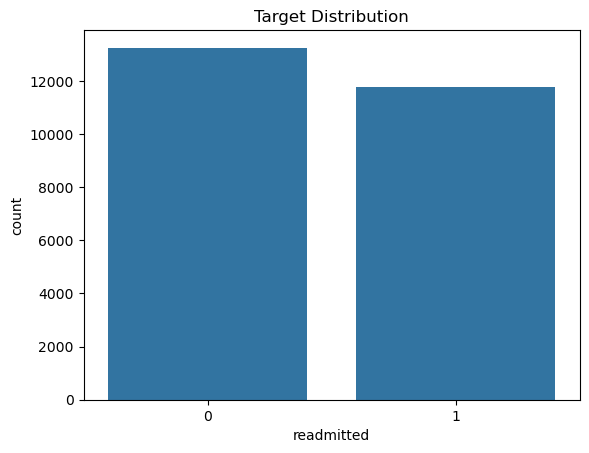

In [51]:
# Count Plot 
sns.countplot(x='readmitted',data=df)
plt.title('Target Distribution')
plt.show()

-----------------------------------------------------------------------------------------------------------------------

##  🧹Data Pre-Proecessing

In [18]:
# Features and Target
X = df.drop('readmitted', axis=1)
y = df['readmitted']

In [19]:
X.shape

(25000, 16)

In [20]:
y.shape

(25000,)

In [55]:
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols= X.select_dtypes(exclude=['object']).columns

print("Categorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)

Categorical Columns:
Index([], dtype='object')

Numerical Columns:
Index(['age', 'time_in_hospital', 'n_lab_procedures', 'n_procedures',
       'n_medications', 'n_outpatient', 'n_inpatient', 'n_emergency',
       'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'glucose_test',
       'A1Ctest', 'change', 'diabetes_med'],
      dtype='object')


In [59]:
for col in categorical_cols:
    print(f"{col}: {X[col].nunique()} unique values")

In [64]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

binary_cols = []

for col in categorical_cols:
    if X[col].nunique() == 2:
        X[col] = le.fit_transform(X[col])
        binary_cols.append(col)

print("Binary encoded columns:")
print(binary_cols)

Binary encoded columns:
[]


In [68]:
remaining_cols = X.select_dtypes(include=['object']).columns
X = pd.get_dummies(X,columns=remaining_cols,drop_first=True)
print(X.shape)

(25000, 16)


In [21]:
# Train - Test Split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2,random_state = 42)

In [22]:
X_train .shape

(20000, 16)

In [23]:
X_test.shape

(5000, 16)

In [24]:
y_train .shape

(20000,)

In [25]:
y_test .shape

(5000,)

-----------------------------------------------------------------------------------------------------------------------

# 🤖 Machine Learning Models

## Logistic Regression

In [26]:
# train the Logistic Regression Model

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [27]:
#Predict the test data
y_pred = model.predict(X_test)

In [28]:
# Calculate the model Accuracy
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy:",accuracy)

Accuracy: 0.6086


In [29]:
#display the confusion matrix
cm = confusion_matrix(y_test,y_pred)
print(cm)

[[2094  564]
 [1393  949]]


In [30]:
# Generate the classification report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.60      0.79      0.68      2658
           1       0.63      0.41      0.49      2342

    accuracy                           0.61      5000
   macro avg       0.61      0.60      0.59      5000
weighted avg       0.61      0.61      0.59      5000



-----------------------------------------------------------------------------------------------------------------------

## Decision Tree 

In [33]:
# Train the decsion Tree model
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

In [34]:
#Predict using the Decision Tree model
dt_pred = dt_model.predict(X_test)

In [35]:
#Calculate decision tree accuracy
dt_accuracy = accuracy_score(y_test,dt_pred)
print("Decision Tree Accuracy:",dt_accuracy)

Decision Tree Accuracy: 0.548


-----------------------------------------------------------------------------------------------------------------------

## Random forest

In [36]:
#Train the Random Forest model
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [37]:
xgb_model = XGBClassifier( n_estimators = 200,
                          learning_rate= 0.1,
                          max_depth=6,
                          random_state=42,
                          eval_metric='logloss'
                         )
xgb_model.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [44]:
xgb_pred = xgb_model.predict(X_test)
from sklearn.metrics import accuracy_score
xgb_accuracy = accuracy_score(y_test,xgb_pred)

print("XGBoost Accuracy:",xgb_accuracy)

XGBoost Accuracy: 0.6094


In [41]:
param_grid = { 'n_estimators': [100,200],
              'max_depth': [10,None],
              'min_samples_split':[2],
              'min_samples_leaf':[1]
             }
grid = GridSearchCV(estimator = RandomForestClassifier(random_state=42),
                    param_grid=param_grid,
                    cv=5,
                    scoring='accuracy',
                    n_jobs=-1
                   )
grid.fit(X_train,y_train)
rf_model = grid.best_estimator_

print("Best Parameters:",grid.best_params_)

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [42]:
#Predict and calculate Accuracy
rf_pred = rf_model.predict(X_test)
#predict using random forest accuracy
rf_accuracy = accuracy_score(y_test,rf_pred)
print("Random Forest Accuracy:",rf_accuracy)

Random Forest Accuracy: 0.6188


In [43]:
# Display Feature importance
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': rf_model .feature_importances_})
feature_importance.sort_values(by='Importance', ascending=False)
print(feature_importance)

              Feature  Importance
0                 age    0.061812
1    time_in_hospital    0.066971
2    n_lab_procedures    0.111935
3        n_procedures    0.046599
4       n_medications    0.110655
5        n_outpatient    0.069181
6         n_inpatient    0.229677
7         n_emergency    0.058006
8   medical_specialty    0.048539
9              diag_1    0.044606
10             diag_2    0.039936
11             diag_3    0.042173
12       glucose_test    0.016394
13            A1Ctest    0.019168
14             change    0.013724
15       diabetes_med    0.020623


In [ ]:
# Plot feature importance
feature_importance = pd.DataFrame({'Feature': X.columns,'Importance': rf_model.feature_importances_})
feature_importance = feature_importance.sort_values(by = 'Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Feature Importance')
plt.show()

-----------------------------------------------------------------------------------------------------------------------

## 💡 Business Insights

### 1. Patients with longer hospital stays are more likely to be readmitted.
### 2. Previous inpatients and emergency visits increase the risk of readmission.
### 3. Some medical diagnoses have a higher impact on readmission than others.
### 4. The model can help hospitals identify high-risk patients before discharge.
### 5. Hospitals can use these predictions to improves patients care and reduce readmission costs.

-----------------------------------------------------------------------------------------------------------------------

## ✅ Conlusion


### * This project successfully developed a machine learning model to predict hospital readmission using patient medical data.
### * The dataset was cleaned, preprocessed, and analyzed before training three machine learning models: Logistic Regression, Decision Tree, and Random Forest. 
### * The models were evaluated using Accuracy, Confusion Matrix, and Classification Report. Among the three models, Logistic Regression achieved the highest accuracy (60.86%), making it the best-performing model for this dataset.
### * The results demonstrate that machine learning can support hospitals in identifying patients at higher risk of readmission, improving patient care, and reducing healthcare costs

-----------------------------------------------------------------------------------------------------------------------